# **응용 : 최단 경로 알고리즘**



---



**(코랩에서)한글 폰트 지정하는 방법**

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 코랩에서 위 코드를 실행시킨 후  반드시 코랩 메뉴: "런타임>세션 다시 시작" 합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (24.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125081 files and direc

In [3]:
# korean font
# Colab: NanumGothic, Mac: AppleGothic, 윈도우: Malgun Gothic
fontname = 'NanumGothic'
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': fontname,        # (코랩)한글 폰트
                     'font.size': 12,
                     'figure.figsize': (8, 5),
                     'axes.unicode_minus':  False }) # 폰트 설정

figsize = (10, 8)

- Networkx에서 한글 테스트

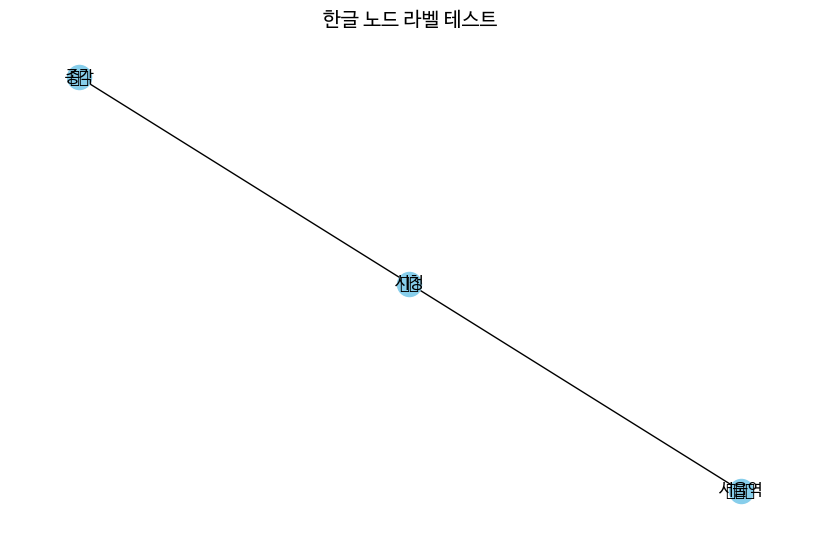

In [4]:
import networkx as nx
import matplotlib.font_manager as fm

# 1. 한글 폰트 경로 지정 (Windows 기준: Nanum 또는 Malgun Gothic 등)
font_path = "C:/Windows/Fonts/malgun.ttf"  # 또는 NanumBarunGothic.ttf의 실제 경로
font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# 2. 폰트 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

G = nx.Graph()
G.add_edge("서울역", "시청")
G.add_edge("시청", "종각")

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, font_size=12, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_family=font_name)
plt.title("한글 노드 라벨 테스트")
plt.show()




---



## 1.서울 지하철 노선의 최단경로 찾기
- 출발역과 도착역을 지정하고 최단 경로를 찾는다.
- networkx.shortest_path 사용
- 데이터 출처: https://data.seoul.go.kr/dataList/OA-15442/S/1/datasetView.do

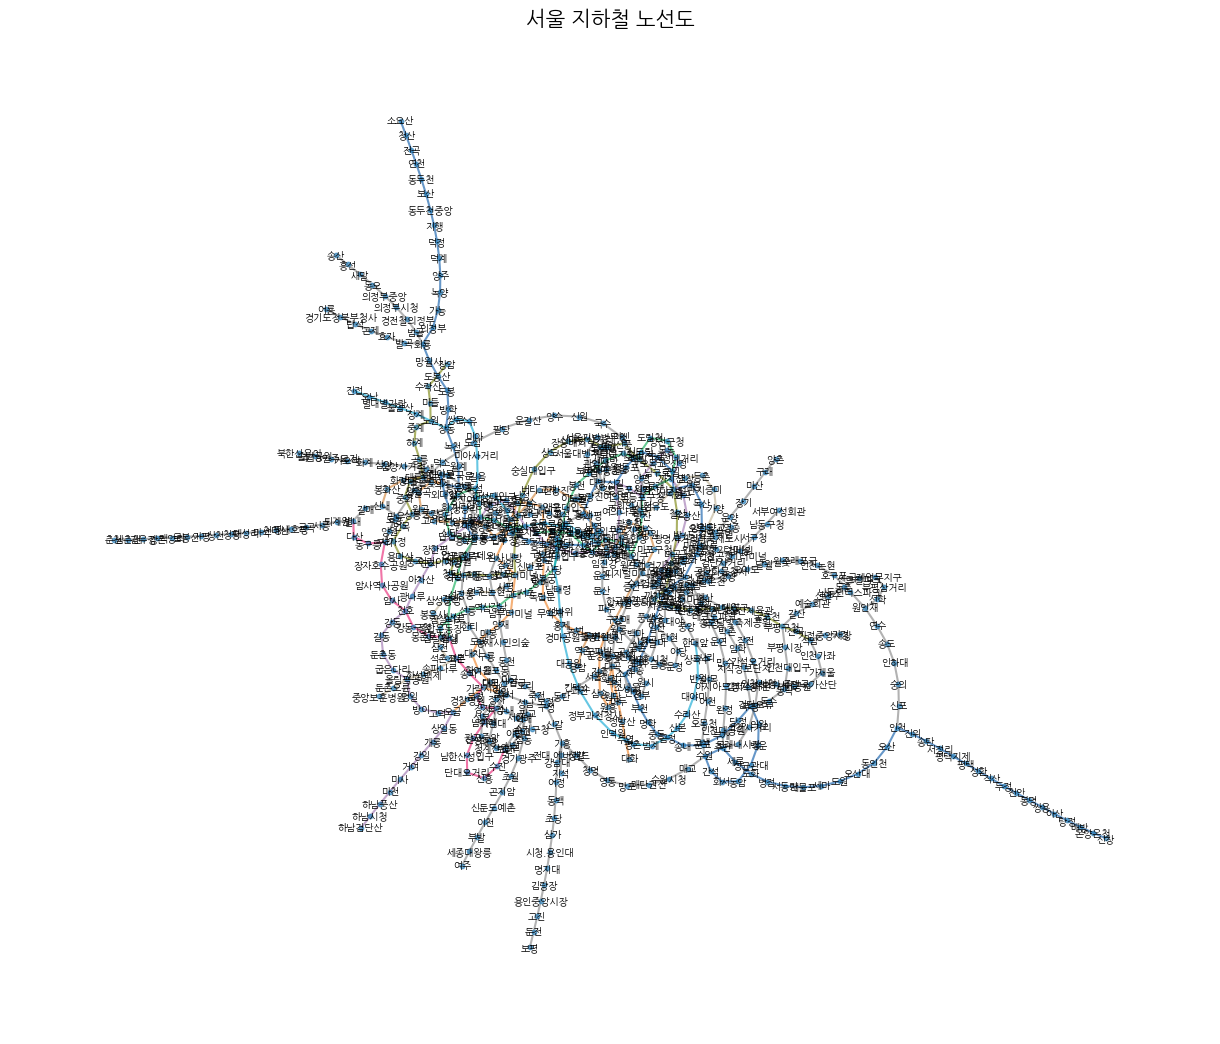

서울 지하철 경로 탐색기입니다.
역명을 입력하세요. '0'을 입력하면 종료됩니다.

----------------------------------------------------------------------------------------------------
🚩 출발역 입력: 가천대
🏁 도착역 입력: 서울역

🔍 출발역 가천대에서 도착역 서울역까지의 최단 경로:
가천대 → 복정 → 수서 → 성남 → 구성 → 동탄 → 킨텍스 → 서울 → 대곡 → 운정중앙 → 연신내 → 구산 → 새절 → 증산 → 디지털미디어시티 → 홍대입구 → 공덕 → 서울역
✅ 총 정거장 수: 17개


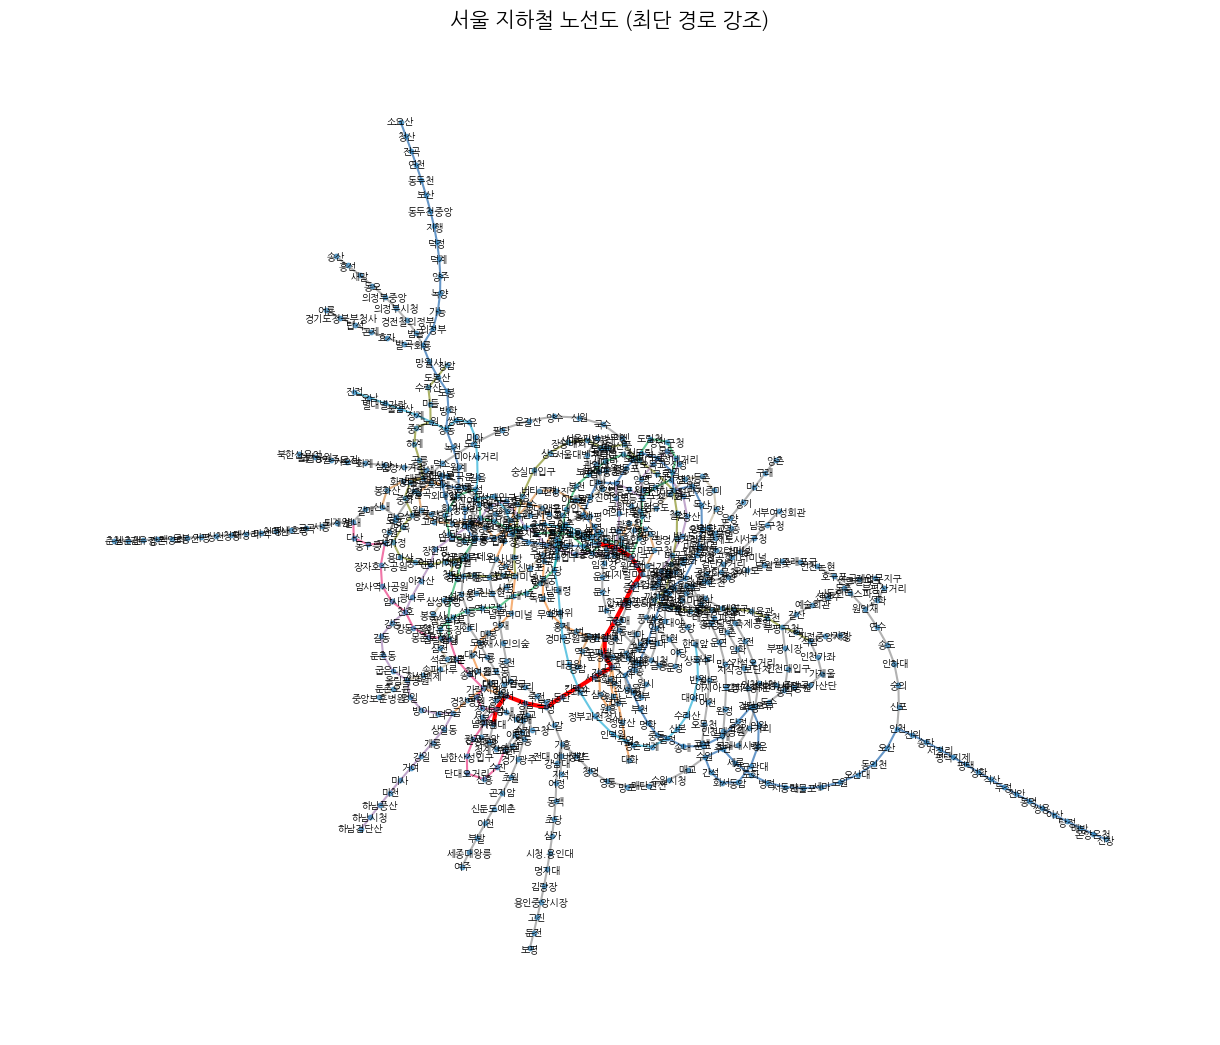

----------------------------------------------------------------------------------------------------
🚩 출발역 입력: 0
프로그램을 종료합니다.


In [28]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import json
import time

# ---------- 설정 ----------
# 1. 한글 폰트 경로 지정 (Windows, Linux 등 환경별로 유동적으로 적용)
try:
    font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
except:
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ---------- 1. 데이터 로드 ----------
def load_subway_data(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["DATA"]

# ---------- 2. 그래프 생성 ----------

# ---------- fr_code 정렬을 위한 커스텀 함수 ----------
def parse_fr_code(fr_code):
    """
    fr_code를 정렬 가능한 튜플로 변환

    fr_code 형식 예시:
    - "100" -> (100, 0, 0)
    - "100-1" -> (100, 1, 0)
    - "P147" -> (147, 0, 1)  # P가 붙은 경우 마지막 플래그를 1로 설정
    - "K411" -> (411, 0, 2)  # K가 붙은 경우 마지막 플래그를 2로 설정

    반환: (주번호, 부번호, 접두사 플래그) 튜플
    """
    fr_code = str(fr_code).strip()

    # P, K 등의 접두사 처리
    prefix_flag = 0
    if fr_code.startswith('P'):
        prefix_flag = 1
        fr_code = fr_code[1:]
    elif fr_code.startswith('K'):
        prefix_flag = 2
        fr_code = fr_code[1:]
    elif fr_code.startswith('A'):
        prefix_flag = 3
        fr_code = fr_code[1:]

    # 숫자-숫자 형식 처리 (예: "100-1")
    if '-' in fr_code:
        parts = fr_code.split('-')
        try:
            main_num = int(parts[0])
            sub_num = int(parts[1])
            return (main_num, sub_num, prefix_flag)
        except:
            return (0, 0, prefix_flag)
    else:
        # 단순 숫자 형식 (예: "100")
        try:
            main_num = int(fr_code)
            return (main_num, 0, prefix_flag)
        except:
            return (0, 0, prefix_flag)

def build_subway_graph(station_data):
    """
    지하철 노선 데이터로부터 그래프를 생성

    핵심 개선사항:
    - fr_code를 기준으로 각 노선의 역들을 정렬
    - 정렬된 순서대로 역들을 연결하여 정확한 경로 생성
    """
    G = nx.Graph()
    line_stations = {}

    # 1단계: 노선별로 역 데이터 수집
    for station in station_data:
        line = station["line_num"].strip()
        name = station["station_nm"].strip()
        fr_code = station.get("fr_code", "")

        if line not in line_stations:
            line_stations[line] = []

        line_stations[line].append({
            'name': name,
            'fr_code': fr_code,
            'line': line
        })

    # 2단계: 각 노선별로 fr_code 기준 정렬 후 그래프 생성
    for line, stations in line_stations.items():
        # fr_code 기준으로 정렬
        sorted_stations = sorted(stations, key=lambda x: parse_fr_code(x['fr_code']))

        # 정렬된 순서대로 역들을 연결
        for i in range(len(sorted_stations) - 1):
            station1 = sorted_stations[i]['name']
            station2 = sorted_stations[i + 1]['name']

            # 간선 추가 (노선 정보 포함)
            G.add_edge(station1, station2, line=line)

        # 2호선은 순환선이므로 처음과 끝을 연결
        if line == "02호선" and len(sorted_stations) > 0:
            first_station = sorted_stations[0]['name']
            last_station = sorted_stations[-1]['name']
            G.add_edge(first_station, last_station, line=line)

    return G



# ---------- 노선별 색상 ----------
LINE_COLORS = {
    "01호선": "#0052A4",
    "02호선": "#00A84D",
    "03호선": "#EF7C1C",
    "04호선": "#00A2D1",
    "05호선": "#996CAC",
    "06호선": "#CD7C2F",
    "07호선": "#747F00",
    "08호선": "#E6186C",
    "09호선": "#BDB092",
    # 기타 노선은 기본 회색 처리
}

# ---------- 3. 그래프 시각화 ----------
def draw_subway_graph(G, pos, path_edges=None, title="서울 지하철 노선도"):
    plt.figure(figsize=(12, 10))

    # 노선별 색상 적용
    edges = G.edges(data=True)
    edge_colors = []
    for u, v, attr in edges:
        # print(f"{u} ↔ {v} : {attr}")
        line = attr.get("line", "기타")
        color = LINE_COLORS.get(line, "gray")
        edge_colors.append(color)

    nx.draw(G, pos, with_labels=False, node_size=10,
            edge_color=edge_colors, width=1.5, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_family=font_name, font_size=7)

    if path_edges:
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.show()



# ---------- 4. 최단 경로 탐색 ----------
def find_shortest_path(G, start, end):
    if start not in G or end not in G:
        raise ValueError("입력한 역이 그래프에 존재하지 않습니다.")

    try:
        path = nx.shortest_path(G, source=start, target=end)
        return path
    except nx.NetworkXNoPath:
        return None

# ---------- 5. 메인 실행 함수 ----------
def run_subway_path_finder(filepath):
    station_data = load_subway_data(filepath)
    G = build_subway_graph(station_data)
    pos = nx.kamada_kawai_layout(G)

    draw_subway_graph(G, pos)

    time.sleep(2)

    print("서울 지하철 경로 탐색기입니다.\n역명을 입력하세요. '0'을 입력하면 종료됩니다.\n")

    while True:
        print('-' * 100)
        start = input("🚩 출발역 입력: ").strip()
        if start == '0':
            print("프로그램을 종료합니다.")
            break

        end = input("🏁 도착역 입력: ").strip()
        if end == '0':
            print("프로그램을 종료합니다.")
            break

        try:
            path = find_shortest_path(G, start, end)
            if path:
                print(f"\n🔍 출발역 {start}에서 도착역 {end}까지의 최단 경로:")
                print(" → ".join(path))
                print(f"✅ 총 정거장 수: {len(path) - 1}개")
                path_edges = list(zip(path[:-1], path[1:]))
                draw_subway_graph(G, pos, path_edges, title="서울 지하철 노선도 (최단 경로 강조)")
            else:
                print("해당 역들 간의 경로가 없습니다.")
        except ValueError as e:
            print(f"오류: {e}")

# ---------- 실행 ----------
if __name__ == "__main__":
    run_subway_path_finder("서울교통공사_노선별 지하철역 정보_all.json")
